In [ ]:
import io
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.svm import SVR

!pip install mlxtend==0.22.0
from mlxtend.feature_selection import SequentialFeatureSelector

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/House_Price_data.csv')
data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [ ]:
data.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [ ]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [ ]:
# Logically Correct Variable and remove price=0 rows
for index in data.index:
  if data.loc[index,'yr_renovated']==0:
    data.loc[index,'yr_renovated']=data.loc[index,'yr_built']

for index in data.index:
  if data.loc[index, 'price'] == 0:
    data.drop(index, inplace=True)

# Reset the index after dropping rows
data.reset_index(drop=True, inplace=True)
len(data)

4551

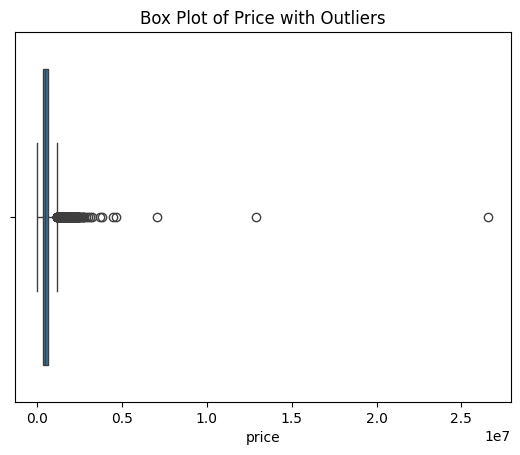

4551


In [ ]:
sns.boxplot(x=data['price'])
plt.title('Box Plot of Price with Outliers')
plt.show()

print(len(data))

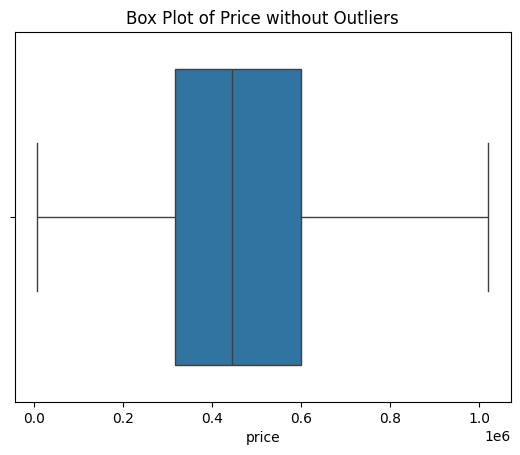

4224


In [ ]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.1 * IQR  # Drop if price<100000
upper_bound = Q3 + 1.1 * IQR

data = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]

sns.boxplot(x=data['price'])
plt.title('Box Plot of Price without Outliers')
plt.show()
print(len(data))

In [ ]:
city_data=data.loc[:,['city','statezip']]
data.drop(columns=['date','street','country','city','statezip'],inplace=True)

city_data=pd.get_dummies(city_data,prefix='loc')
city_data=city_data.replace({False:0,True:1})

encoder = LabelEncoder()
for col in data.select_dtypes("object"):
    data[col] =encoder.fit_transform(data[[col]])

X=data.drop(columns=['price'])
y=data['price']
X.head()

<ipython-input-7-56c4b2cee8b5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['date','street','country','city','statezip'],inplace=True)
<ipython-input-7-56c4b2cee8b5>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  city_data=city_data.replace({False:0,True:1})


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,1966
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,1963
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992
5,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994


<Axes: >

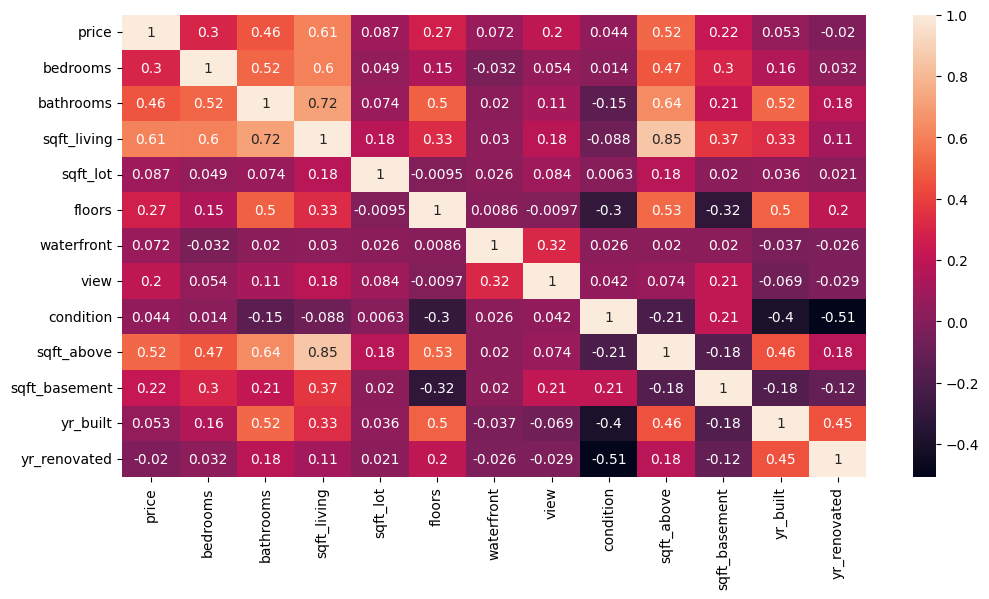

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(data.corr(),annot=True)

In [ ]:
sfs = SequentialFeatureSelector(
    LinearRegression(),
    k_features=(1, X.shape[1]),
    forward=True,
    floating=True,
    scoring='r2',
    cv=5,
    n_jobs=-1,
)
sfs.fit(X, y)
selected_features = list(sfs.k_feature_names_)
print(selected_features)
X=X[selected_features]


['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built']


In [ ]:
X=pd.concat([X,city_data],axis=1)

x = X
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     145.5
Date:                Mon, 25 Nov 2024   Prob (F-statistic):               0.00
Time:                        04:49:45   Log-Likelihood:                -54309.
No. Observations:                4224   AIC:                         1.088e+05
Df Residuals:                    4120   BIC:                         1.095e+05
Df Model:                         103                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    2.508e+05   1.52e+05      1.647      0.100   -4.77e+04    5.49e+05
bedrooms                -8547.3605   2205.975     -3.875      0.000   -1.29e+04   -4222.458
bathrooms                2.197e+04   3631.612      6.049      0.000    1.48e+04    2.91e+04
sqft_living                81.7307      2.269     36.014      0.000      77.281      86.180
sqft_lot                    0.2060      0.045      4.574      0.000       0.118       0.294
floors                  -2.054e+04   4337.674     -4.735      0.000    -2.9e+04    -1.2e+04
view                     3.443e+04   2540.559     13.551      0.000    2.94e+04    3.94e+04
condition                2.298e+04   2505.884      9.169      0.000    1.81e+04    2.79e+04
sqft_above                 76.5139      2.391     32.002      0.000      71.827      81.201
sqft_basement               5.2167      3.094      1.686      0.092      -0.850      11.283
yr_built                  -96.0227     80.009     -1.200      0.230    -252.883      60.838
loc_Algona              -1.081e+05   4.09e+04     -2.644      0.008   -1.88e+05   -2.79e+04
loc_Auburn              -7.444e+04   2.09e+04     -3.567      0.000   -1.15e+05   -3.35e+04
loc_Beaux Arts Village   1.642e+05   8.41e+04      1.954      0.051    -575.316    3.29e+05
loc_Bellevue              1.38e+05   1.94e+04      7.126      0.000       1e+05    1.76e+05
loc_Black Diamond       -1.074e+04   1.69e+04     -0.636      0.525   -4.38e+04    2.23e+04
loc_Bothell              4456.5981   4.74e+04      0.094      0.925   -8.85e+04    9.75e+04
loc_Burien               5.453e+04   1.91e+04      2.852      0.004     1.7e+04     9.2e+04
loc_Carnation           -1.631e+04    1.1e+04     -1.485      0.138   -3.78e+04    5218.085
loc_Clyde Hill           1.589e+05   6.11e+04      2.601      0.009    3.91e+04    2.79e+05
loc_Covington           -1.106e+05   1.64e+04     -6.750      0.000   -1.43e+05   -7.85e+04
loc_Des Moines           9.783e+04   3.77e+04      2.594      0.010    2.39e+04    1.72e+05
loc_Duvall              -2.701e+04   8367.514     -3.228      0.001   -4.34e+04   -1.06e+04
loc_Enumclaw            -7.458e+04      1e+04     -7.437      0.000   -9.42e+04   -5.49e+04
loc_Fall City            1.665e+04   1.59e+04      1.046      0.296   -1.46e+04    4.79e+04
loc_Federal Way         -1.056e+05   3.11e+04     -3.396      0.001   -1.67e+05   -4.46e+04
loc_Inglewood-Finn Hill  2.931e+04   7.01e+04      0.418      0.676   -1.08e+05    1.67e+05
loc_Issaquah             4.798e+04   4.35e+04      1.103      0.270   -3.73e+04    1.33e+05
loc_Kenmore              4878.6844   4.82e+04      0.101      0.919   -8.96e+04    9.94e+04
loc_Kent                -8.819e+04   8750.623    -10.078      0.000   -1.05e+05    -7.1e+04
loc_Kirkland             6.996e+04   2.53e+04  

In [ ]:
## RUN THIS CELL and NEXT CELL TWICE
p_values = model.pvalues

# Create a list of features to remove
features_to_remove = []
for feature, p_value in p_values.items():
    if p_value > 0.05 and feature != 'const' and feature != 'yr_built' and feature != 'sqft_basement':  # Exclude 'const' and 'year_built'
        features_to_remove.append(feature)

# Remove the selected features from X
X = X.drop(columns=features_to_remove)

In [ ]:
x = X
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     218.3
Date:                Mon, 25 Nov 2024   Prob (F-statistic):               0.00
Time:                        04:50:33   Log-Likelihood:                -54389.
No. Observations:                4224   AIC:                         1.089e+05
Df Residuals:                    4157   BIC:                         1.093e+05
Df Model:                          66                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.852e+05   1.58e+05      1.174      0.240   -1.24e+05    4.94e+05
bedrooms          -8356.1455   2220.013     -3.764      0.000   -1.27e+04   -4003.734
bathrooms          2.316e+04   3664.600      6.320      0.000     1.6e+04    3.03e+04
sqft_living          82.0782      2.273     36.116      0.000      77.623      86.534
sqft_lot              0.1830      0.044      4.183      0.000       0.097       0.269
floors            -1.753e+04   4336.442     -4.043      0.000    -2.6e+04   -9030.020
view               3.234e+04   2523.806     12.814      0.000    2.74e+04    3.73e+04
condition          2.394e+04   2516.654      9.513      0.000     1.9e+04    2.89e+04
sqft_above           75.7569      2.358     32.126      0.000      71.134      80.380
sqft_basement         6.3213      3.095      2.043      0.041       0.254      12.389
yr_built            -51.1850     79.746     -0.642      0.521    -207.530     105.160
loc_Algona        -2.017e+05   4.28e+04     -4.711      0.000   -2.86e+05   -1.18e+05
loc_Auburn        -1.754e+05   8128.585    -21.583      0.000   -1.91e+05   -1.59e+05
loc_Bellevue       1.251e+05   9524.253     13.136      0.000    1.06e+05    1.44e+05
loc_Clyde Hill      1.39e+05   7.07e+04      1.965      0.049     329.667    2.78e+05
loc_Covington     -1.325e+05    1.6e+04     -8.271      0.000   -1.64e+05   -1.01e+05
loc_Duvall        -4.366e+04   7609.037     -5.738      0.000   -5.86e+04   -2.87e+04
loc_Enumclaw      -8.924e+04   9515.582     -9.378      0.000   -1.08e+05   -7.06e+04
loc_Federal Way   -1.805e+05   8792.912    -20.530      0.000   -1.98e+05   -1.63e+05
loc_Kent          -1.104e+05   7246.388    -15.230      0.000   -1.25e+05   -9.62e+04
loc_Kirkland       2.452e+04   1.05e+04      2.337      0.020    3946.146    4.51e+04
loc_Maple Valley  -7.162e+04   5265.028    -13.602      0.000   -8.19e+04   -6.13e+04
loc_Medina        -2.237e+05   4.77e+04     -4.685      0.000   -3.17e+05    -1.3e+05
loc_Mercer Island  1.147e+05   7251.669     15.818      0.000       1e+05    1.29e+05
loc_North Bend    -3.966e+04   6999.693     -5.666      0.000   -5.34e+04   -2.59e+04
loc_Pacific        -8.48e+04   1.96e+04     -4.330      0.000   -1.23e+05   -4.64e+04
loc_Redmond        1.087e+05   7459.379     14.572      0.000    9.41e+04    1.23e+05
loc_Renton        -1.289e+05   8240.203    -15.648      0.000   -1.45e+05   -1.13e+05
loc_Sammamish      8.173e+04   8506.322      9.608      0.000    6.51e+04    9.84e+04
loc_Seattle        3.523e+04   8524.936      4.132      0.000    1.85e+04    5.19e+04
loc_Skykomish     -6.967e+04   2.76e+04     -2.523      0.012   -1.24e+05   -1.55e+04
loc_Yarrow Point  -1.934e+05   7.07e+04     -2.734      0.006   -3.32e+05   -5.47e+04
loc_WA 98004        2.07e+05   2.09e+04      9.930      0.000    1.66e+05

In [ ]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Print the VIF
pd.set_option("display.max_rows", None, "display.max_columns", None)
print(vif_data)

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


              feature        VIF
0            bedrooms  26.676513
1           bathrooms  26.579087
2         sqft_living        inf
3            sqft_lot   1.321531
4              floors  19.781379
5                view   1.219688
6           condition  31.555544
7          sqft_above        inf
8       sqft_basement        inf
9            yr_built  67.038012
10         loc_Algona   1.008915
11         loc_Auburn   1.270894
12       loc_Bellevue   2.125474
13     loc_Clyde Hill   1.099989
14      loc_Covington        inf
15         loc_Duvall        inf
16       loc_Enumclaw        inf
17    loc_Federal Way   1.232948
18           loc_Kent        inf
19       loc_Kirkland   1.986195
20   loc_Maple Valley        inf
21         loc_Medina        inf
22  loc_Mercer Island        inf
23     loc_North Bend        inf
24        loc_Pacific        inf
25        loc_Redmond   1.348814
26         loc_Renton   2.158555
27      loc_Sammamish   1.288650
28        loc_Seattle  11.331158
29      lo

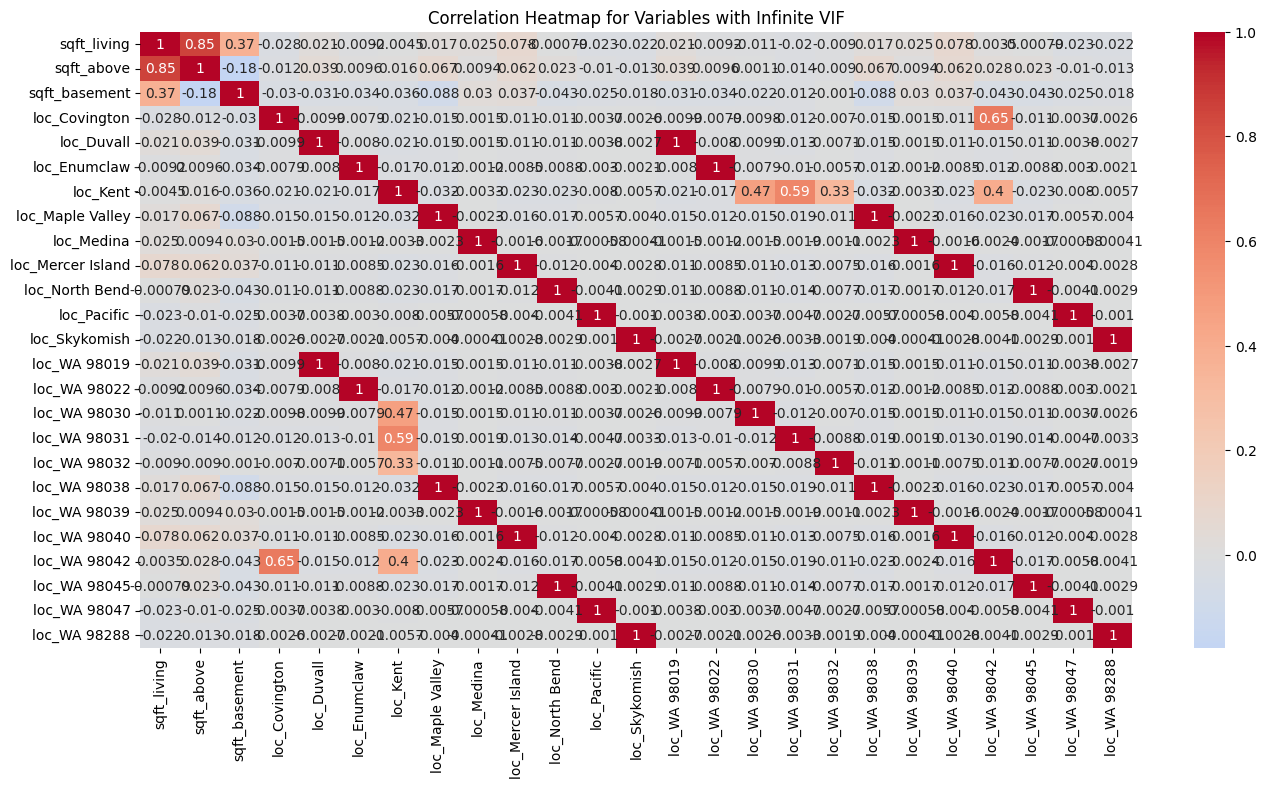

In [ ]:
inf_vif_features = vif_data[vif_data['VIF'] == float('inf')]['feature'].tolist()

# Sub data frame with features of VIF= inf
inf_vif_df = X[inf_vif_features]

# Correlation matrix of potentially intercorrelated features
correlation_matrix = inf_vif_df.corr()

# Visual Heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap for Variables with Infinite VIF')
plt.show()

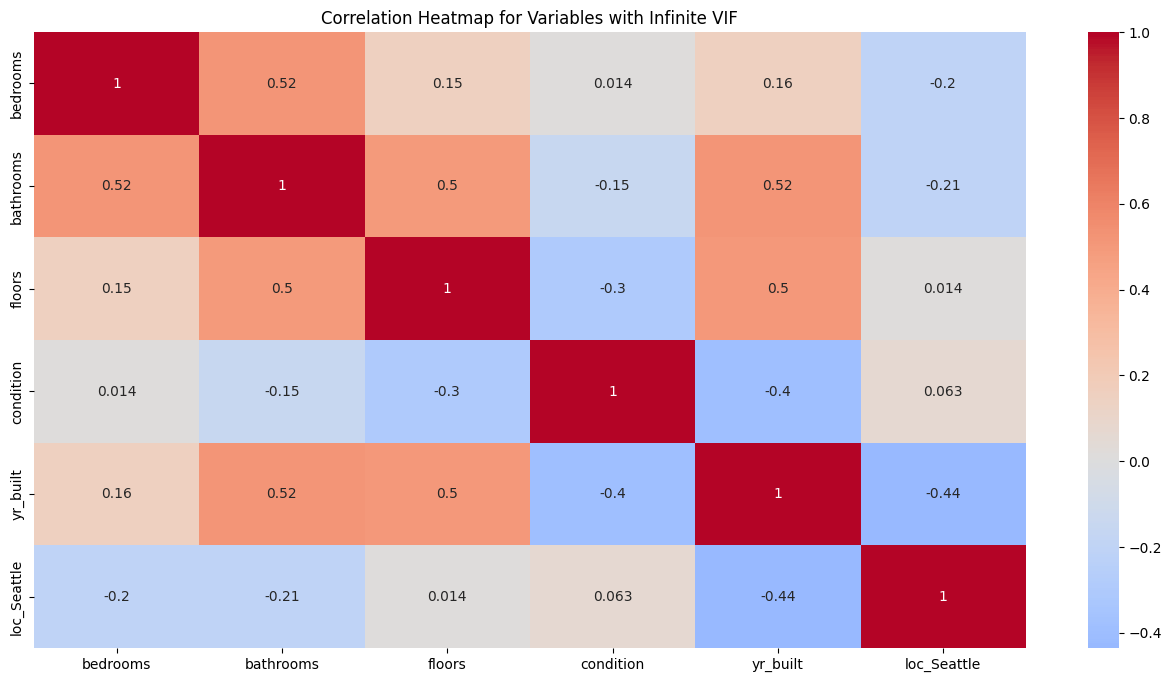

In [ ]:
inf_vif_features = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] != float('inf'))]['feature'].tolist()

# 2. Create a sub-dataframe with only these features
inf_vif_df = X[inf_vif_features]

# 3. Calculate correlation matrix for this sub-dataframe
correlation_matrix = inf_vif_df.corr()

# 4. Plot the heatmap
plt.figure(figsize=(16, 8))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap for Variables with Infinite VIF')
plt.show()

In [ ]:
# Combining multicorrelated features together to reduce feature size and dropping unnecessary features with infinite VIF

X['sqft_living']=X['sqft_living']+(0.85*X['sqft_above'])+(0.37*X['sqft_basement'])
X['condition']=X['condition']*X['yr_built']
X.drop(columns=['sqft_above','yr_built','sqft_basement','loc_WA 98019','loc_WA 98022','loc_WA 98038','loc_WA 98039','loc_WA 98040',
                'loc_WA 98045','loc_WA 98047','loc_WA 98288','loc_WA 98030','loc_WA 98031','loc_WA 98032','loc_WA 98042'],inplace=True)
print(X.shape)

(4224, 61)


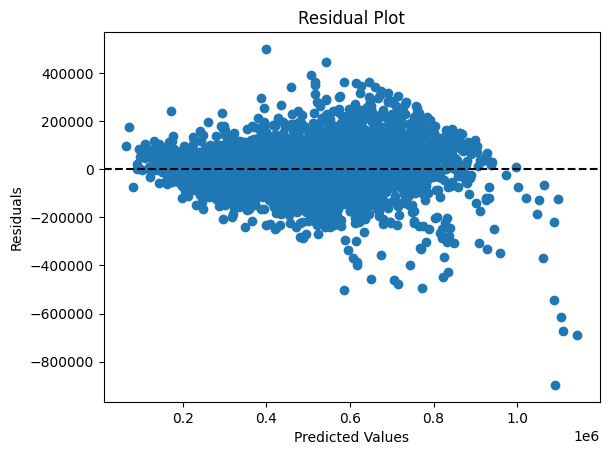

In [ ]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
res=y-y_pred

plt.scatter(y_pred,res)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

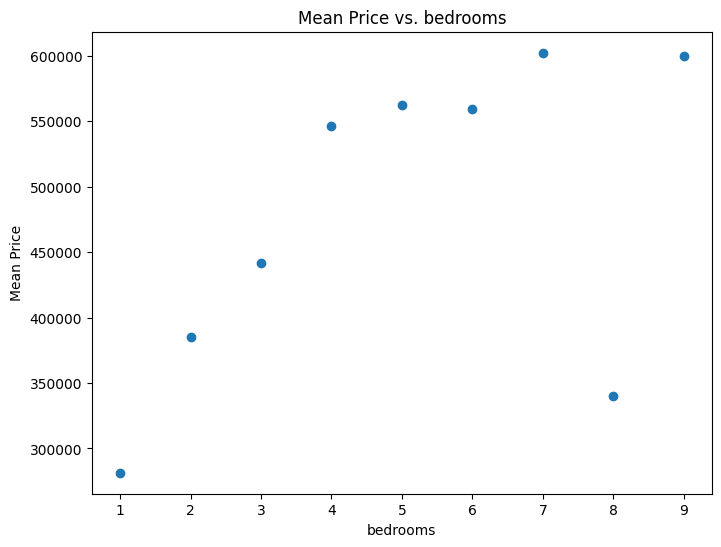

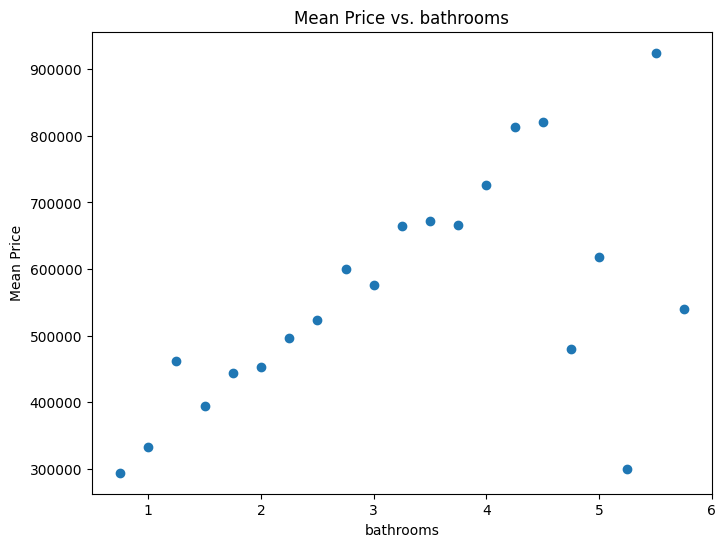

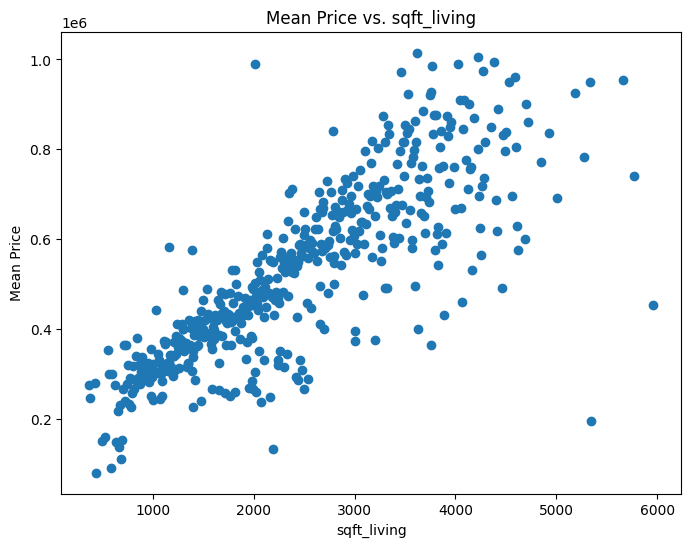

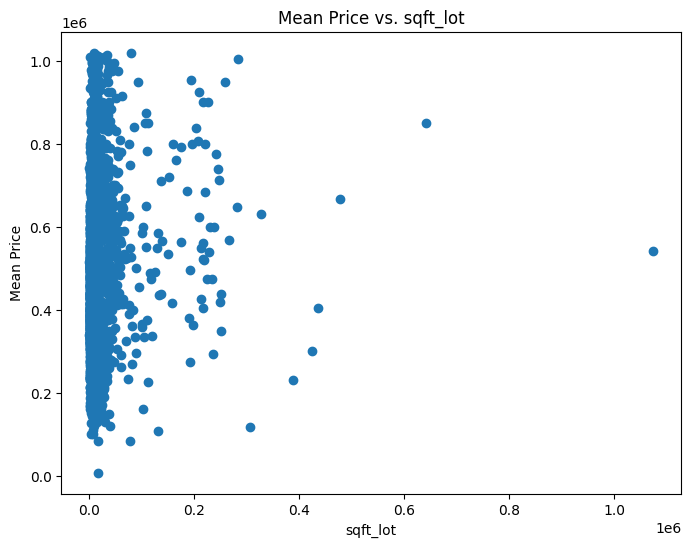

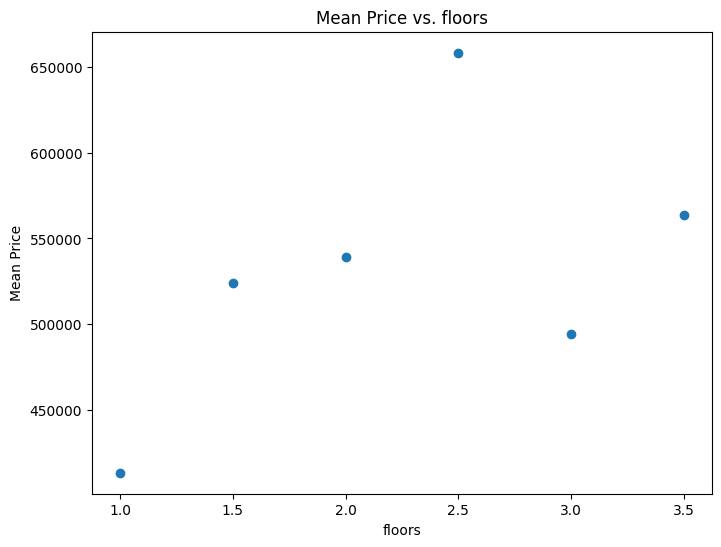

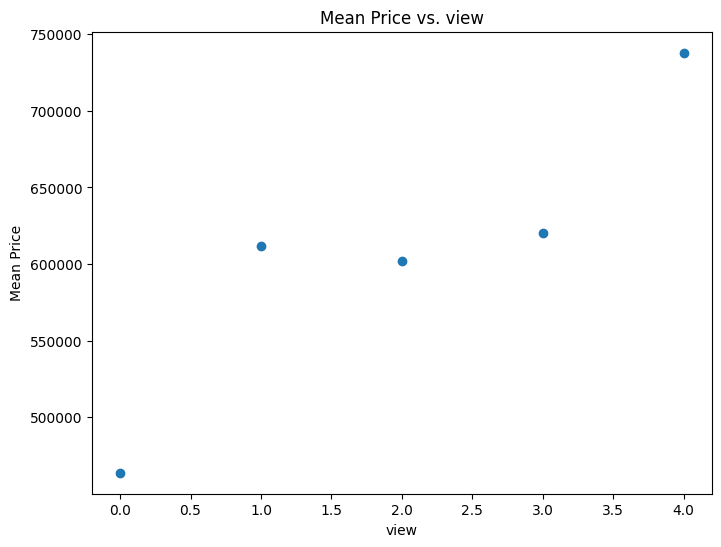

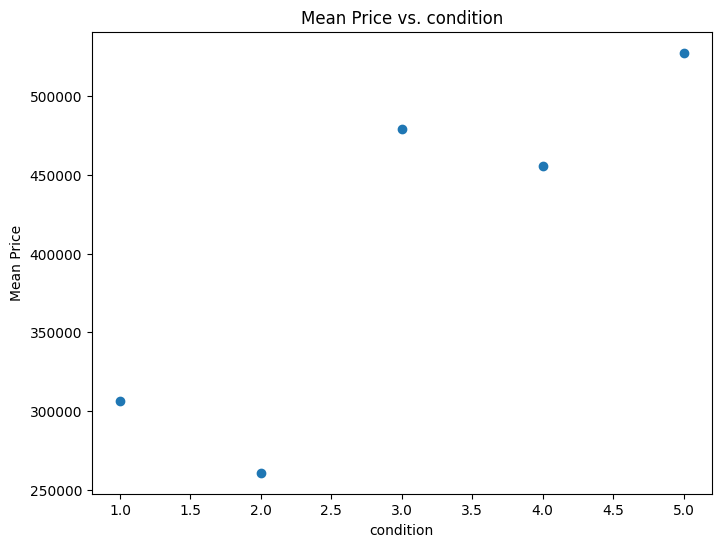

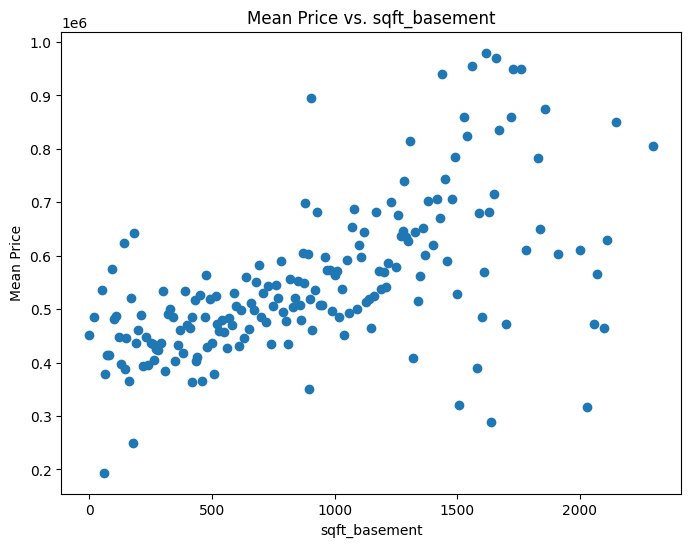

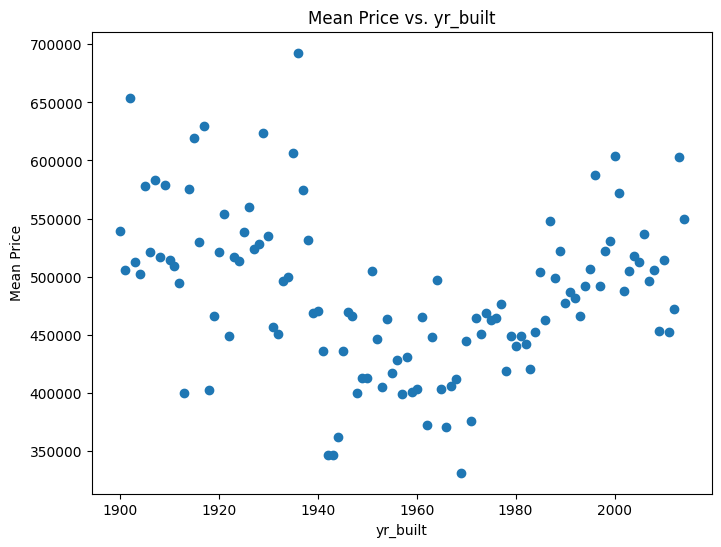

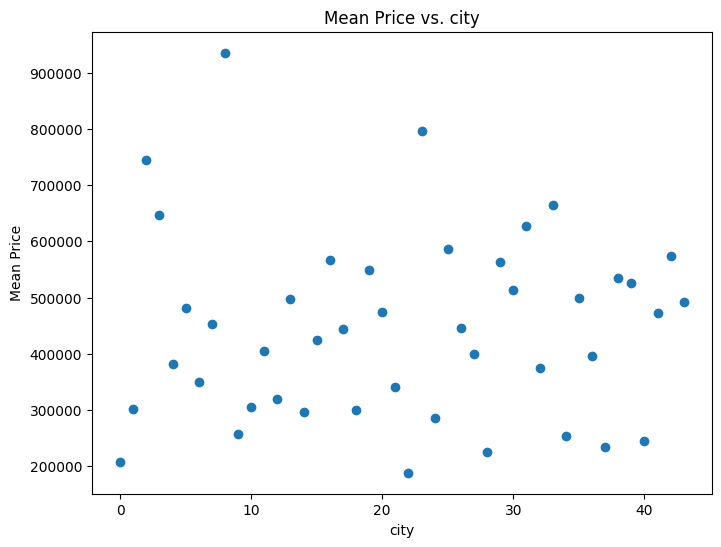

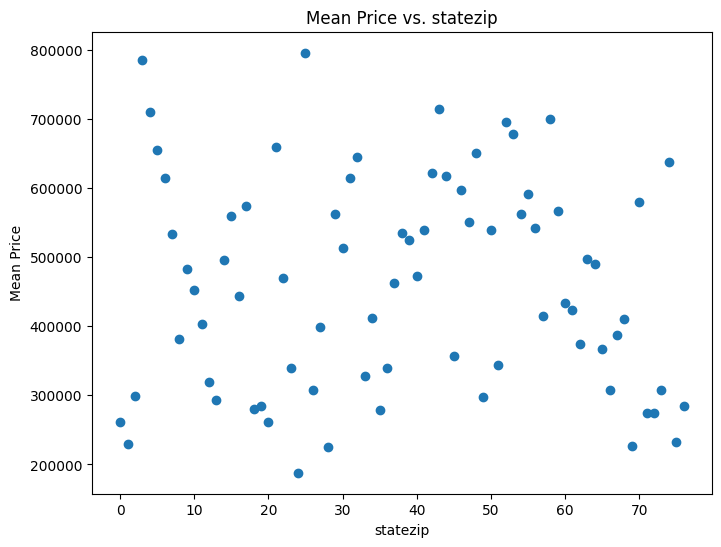

In [ ]:
for column in X.columns[:8]:
    if X[column].dtype in ['int64', 'int32', 'float64']:  # Check for discrete (integer) columns
        # Calculate mean price for each discrete value
        mean_prices = data.groupby(column)['price'].mean()

        plt.figure(figsize=(8, 6))
        plt.scatter(mean_prices.index, mean_prices.values, marker='o')  # Plot mean values
        plt.title(f'Mean Price vs. {column}')
        plt.xlabel(column)
        plt.ylabel('Mean Price')
        plt.show()

    else:  # For continuous columns, plot regular scatter
        plt.figure(figsize=(8, 6))
        plt.scatter(X[column], y,marker='o')
        plt.title(f'Scatter Plot of Price vs. {column}')
        plt.xlabel(column)
        plt.ylabel('Price')
        plt.show()

In [ ]:
# Scale data
scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=162)

X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,loc_Algona,loc_Auburn,loc_Bellevue,loc_Clyde Hill,loc_Covington,loc_Duvall,loc_Enumclaw,loc_Federal Way,loc_Kent,loc_Kirkland,loc_Maple Valley,loc_Medina,loc_Mercer Island,loc_North Bend,loc_Pacific,loc_Redmond,loc_Renton,loc_Sammamish,loc_Seattle,loc_Skykomish,loc_Yarrow Point,loc_WA 98004,loc_WA 98005,loc_WA 98008,loc_WA 98033,loc_WA 98056,loc_WA 98059,loc_WA 98102,loc_WA 98103,loc_WA 98105,loc_WA 98106,loc_WA 98107,loc_WA 98108,loc_WA 98109,loc_WA 98112,loc_WA 98115,loc_WA 98116,loc_WA 98117,loc_WA 98118,loc_WA 98119,loc_WA 98122,loc_WA 98125,loc_WA 98133,loc_WA 98136,loc_WA 98144,loc_WA 98146,loc_WA 98148,loc_WA 98166,loc_WA 98168,loc_WA 98177,loc_WA 98178,loc_WA 98188,loc_WA 98198,loc_WA 98199
0,-0.387820,-0.822630,-0.791583,-0.179693,0.019629,-0.261564,-0.716847,-0.034425,-0.207896,-0.230443,-0.021765,-0.099003,-0.100215,-0.080207,-0.188542,-0.212805,-0.200983,-0.151684,-0.015388,-0.106076,-0.109448,-0.037716,-0.234965,-0.271005,-0.199704,-0.718059,-0.02666,-0.021765,-0.083144,-0.078698,-0.102598,-0.127914,-0.139825,-0.155719,-0.067219,-0.186512,-0.08737,-0.125988,-0.116957,-0.102598,-0.063568,-0.101413,-0.172458,-0.120038,-0.176777,-0.136263,-0.096535,-0.125015,-0.145016,6.664785,-0.112724,-0.129812,-0.112724,-0.061663,-0.113796,-0.125015,-0.106076,-0.106076,-0.072357,-0.115912,-0.113796
2,-0.387820,-0.110218,0.001726,-0.067165,-0.911963,-0.261564,0.857114,-0.034425,-0.207896,-0.230443,-0.021765,-0.099003,-0.100215,-0.080207,-0.188542,4.699145,-0.200983,-0.151684,-0.015388,-0.106076,-0.109448,-0.037716,-0.234965,-0.271005,-0.199704,-0.718059,-0.02666,-0.021765,-0.083144,-0.078698,-0.102598,-0.127914,-0.139825,-0.155719,-0.067219,-0.186512,-0.08737,-0.125988,-0.116957,-0.102598,-0.063568,-0.101413,-0.172458,-0.120038,-0.176777,-0.136263,-0.096535,-0.125015,-0.145016,-0.150042,-0.112724,-0.129812,-0.112724,-0.061663,-0.113796,-0.125015,-0.106076,-0.106076,-0.072357,-0.115912,-0.113796
3,-0.387820,0.245988,-0.253020,-0.176403,-0.911963,-0.261564,0.847666,-0.034425,-0.207896,4.339468,-0.021765,-0.099003,-0.100215,-0.080207,-0.188542,-0.212805,-0.200983,-0.151684,-0.015388,-0.106076,-0.109448,-0.037716,-0.234965,-0.271005,-0.199704,-0.718059,-0.02666,-0.021765,-0.083144,-0.078698,9.746794,-0.127914,-0.139825,-0.155719,-0.067219,-0.186512,-0.08737,-0.125988,-0.116957,-0.102598,-0.063568,-0.101413,-0.172458,-0.120038,-0.176777,-0.136263,-0.096535,-0.125015,-0.145016,-0.150042,-0.112724,-0.129812,-0.112724,-0.061663,-0.113796,-0.125015,-0.106076,-0.106076,-0.072357,-0.115912,-0.113796
4,0.752955,0.602194,-0.263922,-0.107519,-0.911963,-0.261564,0.888609,-0.034425,-0.207896,-0.230443,-0.021765,-0.099003,-0.100215,-0.080207,-0.188542,-0.212805,-0.200983,-0.151684,-0.015388,-0.106076,-0.109448,-0.037716,4.255951,-0.271005,-0.199704,-0.718059,-0.02666,-0.021765,-0.083144,-0.078698,-0.102598,-0.127914,-0.139825,-0.155719,-0.067219,-0.186512,-0.08737,-0.125988,-0.116957,-0.102598,-0.063568,-0.101413,-0.172458,-0.120038,-0.176777,-0.136263,-0.096535,-0.125015,-0.145016,-0.150042,-0.112724,-0.129812,-0.112724,-0.061663,-0.113796,-0.125015,-0.106076,-0.106076,-0.072357,-0.115912,-0.113796
5,-1.528596,-1.535042,-1.410096,-0.222418,-0.911963,-0.261564,-0.757003,-0.034425,-0.207896,-0.230443,-0.021765,-0.099003,-0.100215,-0.080207,-0.188542,-0.212805,-0.200983,-0.151684,-0.015388,-0.106076,-0.109448,-0.037716,-0.234965,-0.271005,-0.199704,1.392644,-0.02666,-0.021765,-0.083144,-0.078698,-0.102598,-0.127914,-0.139825,-0.155719,-0.067219,-0.186512,-0.08737,-0.125988,-0.116957,-0.102598,-0.063568,-0.101413,5.798530,-0.120038,-0.176777,-0.136263,-0.096535,-0.125015,-0.145016,-0.150042,-0.112724,-0.129812,-0.112724,-0.061663,-0.113796,-0.125015,-0.106076,-0.106076,-0.072357,-0.115912,-0.113796


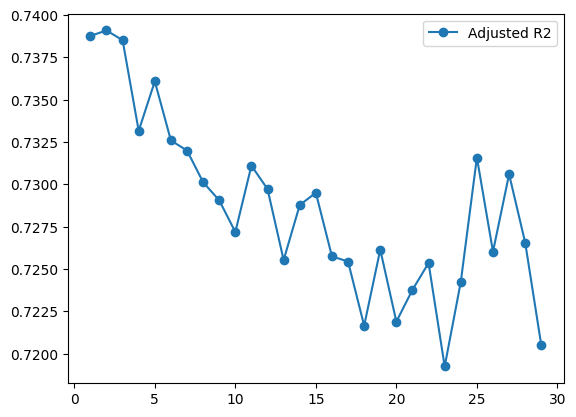

In [ ]:
# Optimizing max_features paramter of Random Forest Regressor
fet_vals=range(1,30)
mse_scores=[]
adj_r2_scores=[]
for i in fet_vals:
  RF_car = RFR(max_features=i,
            random_state=0).fit(X_train, y_train)
  y_pred = RF_car.predict(X_test)
  mse_scores.append(mean_squared_error(y_test, y_pred))
  r2=r2_score(y_test, y_pred)
  adj_r2_scores.append(1-(((1-r2)*(len(X_test)-1))/(len(X_test)-X_test.shape[1]-1)))

#plt.plot(fet_vals, mse_scores,marker='o', label='MSE')
plt.plot(fet_vals, adj_r2_scores,marker='o', label='Adjusted R2')
plt.legend()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Optimzing other paramters in RFR using randomized gird search
param_distributions = {
    'n_estimators': [150,175,200,225,250],
    'max_depth': [None, 10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2],
}

rf = RandomForestRegressor(max_features=2,random_state=162)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=15, scoring='neg_mean_squared_error',
                                   cv=3, n_jobs=-1, verbose=2, random_state=42)

random_search.fit(X, y)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

best_rf_model = random_search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters: {'n_estimators': 225, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best score: -10152534191.77873


In [ ]:
# Features ranked by importance by RFR
feature_imp = pd.DataFrame(
    {'importance':best_rf_model.feature_importances_},
    index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
sqft_living,0.412534
statezip,0.144845
city,0.123589
yr_built,0.089749
sqft_lot,0.079189
bathrooms,0.055649
sqft_basement,0.030320
bedrooms,0.018663
view,0.017463
floors,0.014041


In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# Ridge regression
ridge = Ridge()
param_grid_ridge = {'alpha': np.logspace(-5, 5, 10)}
grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, scoring='r2', cv=5)
grid_search_ridge.fit(X_train, y_train)
print("Best Ridge alpha:", grid_search_ridge.best_params_)

# Lasso regression
lasso = Lasso()
param_grid_lasso = {'alpha': np.logspace(-5, 5, 10)}
grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, scoring='r2', cv=10)
grid_search_lasso.fit(X_train, y_train)
print("Best Lasso alpha:", grid_search_lasso.best_params_)

Best Ridge alpha: {'alpha': 46.41588833612782}
Best Lasso alpha: {'alpha': 599.4842503189421}


In [ ]:
#Optimizing ElasticNet parameters
param_distributions = {
    'alpha': np.logspace(-5, 5, 100),
    'l1_ratio': np.arange(0, 1, 0.01)
}

elastic_net = ElasticNet()

random_search = RandomizedSearchCV(estimator=elastic_net, param_distributions=param_distributions, n_iter=100, y scoring='r2', cv=5, verbose=2, random_state=42,n_jobs=-1)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

best_EN_model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'l1_ratio': 0.56, 'alpha': 0.03430469286314919}
Best score: 0.7527969596463844


In [ ]:
# Simple SVR prameter gridsearch
param_grid = {'C': [1200,1300,1400], 'epsilon': [0.02,0.03,0.04]}
grid_search = GridSearchCV(SVR(kernel='linear'), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Best SVR parameters: {grid_search.best_params_}")
print(f"Best R^2 score: {grid_search.best_score_}")

Best SVR parameters: {'C': 1400, 'epsilon': 0.02}
Best R^2 score: 0.7512905524348247


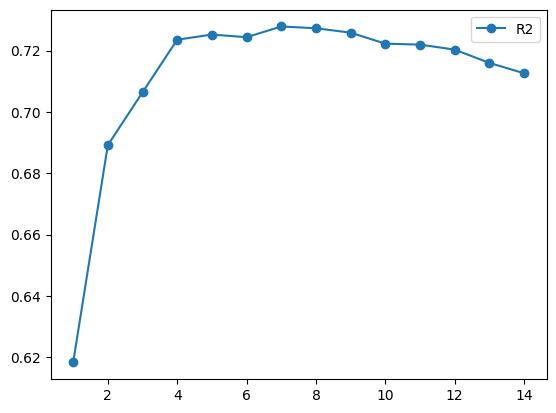

In [ ]:
# Optimizing n_neighbors paramter of K Nearest Neighbors
fet_vals=range(1,15)
r2_scores=[]
for i in fet_vals:
  RF_car = KNeighborsRegressor(n_neighbors=i).fit(X_train, y_train)
  y_pred = RF_car.predict(X_test)
  mse_scores.append(mean_squared_error(y_test, y_pred))
  r2_scores.append(r2_score(y_test, y_pred))

plt.plot(fet_vals, r2_scores,marker='o', label='R2')
plt.legend()


In [ ]:
#Optimizing rest of KNN paramters using gridsearch
param_grid = {
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'leaf_size': [1,5,10],
    'p': [1, 2],
}

knn = KNeighborsRegressor(n_neighbors=7)

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='r2',n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R^2 score: {grid_search.best_score_}")


Best parameters: {'algorithm': 'auto', 'leaf_size': 1, 'p': 1, 'weights': 'distance'}
Best R^2 score: 0.7104623966386483


In [ ]:
#XGB parameter optimiztion
xgb = XGBRegressor(objective='reg:squarederror', random_state=162)

param_dist = {
    'n_estimators': np.arange(100, 500, 100),
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0],
    'tree_method': ['auto', 'gpu_hist']
}

random_search = RandomizedSearchCV(xgb, param_dist, n_iter=50, cv=5, scoring='r2', n_jobs=-1)
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best R^2 score: {random_search.best_score_}")


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
120 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py", line 1108, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 726, in inner_f
 

Best parameters: {'tree_method': 'auto', 'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
Best R^2 score: 0.7651854606418507


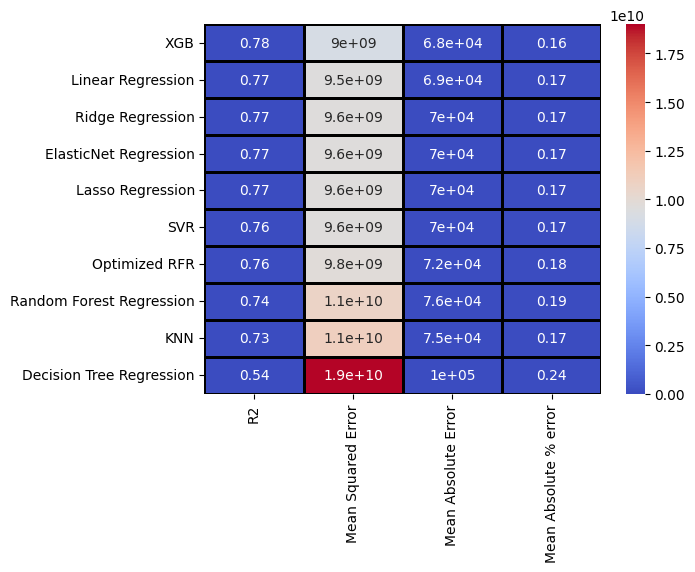

In [ ]:
# Model results and evaluation metrics

model_dic = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=50),
    "Lasso Regression": Lasso(alpha=600),
    "ElasticNet Regression": best_EN_model,
    "Decision Tree Regression": DTR(),
    "Random Forest Regression": RFR(max_features=9, random_state=162),
    "Optimized RFR": best_rf_model,
    "SVR": SVR(kernel='linear',C=1400,epsilon=0.02),
    "XGB": XGBRegressor(n_estimators=400,tree_method='auto',subsample=0.8,reg_lambda=0.1,reg_alpha=0.1,min_child_weight=1,max_depth=5,learning_rate=0.05,gamma=0,colsample_bytree=1.0),
    "KNN": KNeighborsRegressor(n_neighbors=7,algorithm='auto',leaf_size=1,weights='distance',p=1),
}

metric_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    metric_dic[i]={'R2':r2_score(y_test,y_pred),
                "Mean Squared Error"  :mean_squared_error(y_test,y_pred),
                "Mean Absolute Error"  :mean_absolute_error(y_test,y_pred),
                "Mean Absolute % error"  :mean_absolute_percentage_error(y_test, y_pred)}

metric_dic=pd.DataFrame(metric_dic)
metric_dic_transposed = metric_dic.T
metric_dic_sorted = metric_dic_transposed.sort_values(by=['R2'],ascending=False)

sns.heatmap(metric_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()